# Лабораторная работа 1. Что сохраняет представление текста?

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.misc.plistlib import Data
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
import re
from pymorphy3 import MorphAnalyzer

RANDOM_SEED = 42

## Часть 1. Представление текста в задаче классификации


### 1. Первичный анализ данныx


In [3]:
url = "https://raw.githubusercontent.com/sismetanin/rureviews/master/women-clothing-accessories.3-class.balanced.csv"

df = pd.read_csv(url, sep="\t")
df

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative
...,...,...
89995,сделано достаточно хорошо. на ткани сделан рис...,positive
89996,Накидка шикарная. Спасибо большое провдо линяе...,positive
89997,спасибо большое ) продовца рекомендую.. заказа...,positive
89998,Очень довольна заказом! Меньше месяца в РБ. К...,positive


==> Вывод основной информации о датасете

In [4]:
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} колонок")

print("\nРаспределение классов:")
print(df['sentiment'].value_counts())

print("\nДоли классов:")
print(df['sentiment'].value_counts(normalize=True))

Размер датасета: 90000 строк и 2 колонок

Распределение классов:
sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64

Доли классов:
sentiment
negative    0.333333
neautral    0.333333
positive    0.333333
Name: proportion, dtype: float64


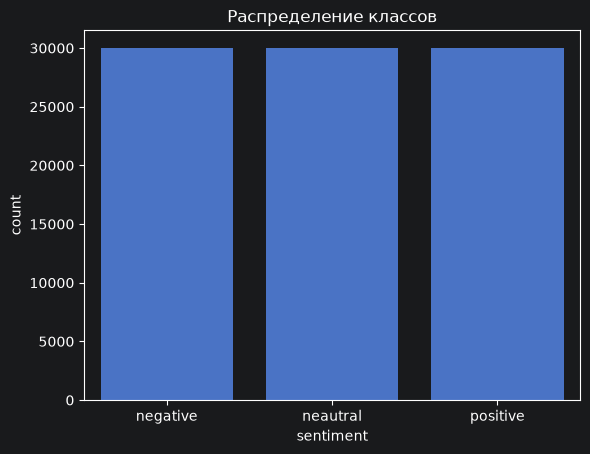

In [5]:
sns.countplot(data=df, x="sentiment")
plt.title("Распределение классов")
plt.show()

==> Вывод основных характеристик длины текстов

In [6]:
df["lengthOfStr"] = df['review'].str.len() # в символах
df["countOfWords"] = df["review"].str.split().str.len() # количество слов в строке

print("Статистика по длине в символах:")
print(df['lengthOfStr'].describe())

print("\nСтатистика по длине в словах:")
print(df['countOfWords'].describe())

Статистика по длине в символах:
count    90000.000000
mean       130.069311
std        126.137185
min          1.000000
25%         51.000000
50%         91.000000
75%        164.000000
max       1007.000000
Name: lengthOfStr, dtype: float64

Статистика по длине в словах:
count    90000.000000
mean        20.011144
std         19.885001
min          0.000000
25%          8.000000
50%         14.000000
75%         25.000000
max        193.000000
Name: countOfWords, dtype: float64


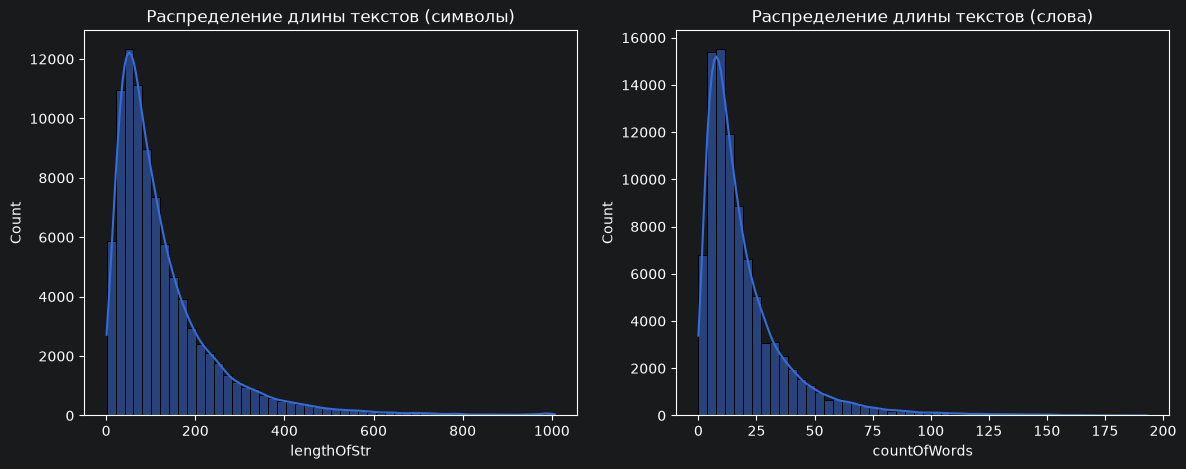

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['lengthOfStr'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Распределение длины текстов (символы)')

sns.histplot(df['countOfWords'], bins=50, ax=axes[1], kde=True)
axes[1].set_title('Распределение длины текстов (слова)')
plt.show()

==> Вывод парочки случайных примеров для каждого класса

In [8]:
examples = df.groupby('sentiment').sample(n=2)

for _, row in examples.iterrows():
    print(f"Класс: {row['sentiment']}")
    print(f"Текст: {row['review']}")
    print()

Класс: neautral
Текст: Сшито так себе, нитки торчат швы кривые

Класс: neautral
Текст: Выписала у этого продавца 4-ю рубашку, три рубашки до этого очень понравились, эта к сожалению совсем не понравилась. На груди  очень неудачный крой, нелепо выглядит-чашечки для такого размера маленькие, в груди очень широко, и шнуровка на спинке рубашки не спасает, носить это нельзя-неудобно и некрасиво, надо нести в мастерскую перешивать или будет лежать не нужной. Сожалею, поэтому 3 звезды.Покупка не понравилась. Всегда читаю отзывы на товар, но в данном случае так как уже покупала у этого продавца, была уверена в размере, а вот  в отзывах как раз  пишут об этой проблеме другие покупательницы, сама виновата ---надо читать отзывы, они хорошо помогают.

Класс: negative
Текст: все ужасно деньги не вернули , спор закрыли , джинсы просвечивает и нет пуговицы

Класс: negative
Текст: товар так ко мне не пришел ( на моей практике это первый раз), продавец отвечал на все мои письма.Деньги вернули,спасибо и

==> Поищем примеры, для которых метка класса кажется неоднозначной или плохо согласуется с содержанием текста

- Класс: positive;
Текст: Купточка хорошая, но вот с размерами беда. Прочитав отзывы на 46 размер заказала XL - мало, максимум на 44, и то я бы сказала скорее 42-44, особенно если на свитерок.

Видим противопоставление, но оценка положительная, тут, скорее, подойдет негативная или нейтральная

- Класс: neautral;
Текст: Есть зацепки,тонкий Ден.На рост 175 подошло.Одеть 1раз можно..

Видим явные негативные моменты по поводу товара, что больше подходит для негативной метки
- Класс: neautral;
Текст: материал плохой.с картинкой не сравнить

Также больше походит на негативную метку


### 2. Разбиение данных

In [9]:
df = df.drop(columns=['lengthOfStr', 'countOfWords'], errors='ignore')

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df['sentiment']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [10]:
print(f"Train: {train_df.shape[0]} примеров")
print(f"Test: {test_df.shape[0]} примеров")

Train: 72000 примеров
Test: 18000 примеров


==> Сохраняем разбиение в таблицы

In [11]:
train_df.to_csv("train_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

==> Обучаем vectorizer на выборке для обучения

In [12]:
X_train, y_train = train_df['review'], train_df['sentiment']
X_test, y_test = test_df['review'], test_df['sentiment']

In [13]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.5,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [14]:
model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7512

Classification report:
              precision    recall  f1-score   support

    neautral       0.64      0.67      0.65      6000
    negative       0.74      0.72      0.73      6000
    positive       0.89      0.87      0.88      6000

    accuracy                           0.75     18000
   macro avg       0.75      0.75      0.75     18000
weighted avg       0.75      0.75      0.75     18000




### 3. Сравнение разреженных представлений

In [21]:
def test_pres(name, vectorizer, X_train, X_test, y_train, y_test):
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    vocab_size    = len(vectorizer.vocabulary_)
    train_shape   = X_train_vec.shape
    nonzero_share = X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])

    return {
        'name': name,
        'vocab_size': vocab_size,
        'train_shape': train_shape,
        'nonzero_share': nonzero_share,
        'accuracy': accuracy,
        'macro_f1': f1,
    }

==> Запускаем на каждом из вариантов представления, что от нас требуют

In [23]:
pres = [
    ("Count, unigrams",
     CountVectorizer(ngram_range=(1, 1))),

    ("TF-IDF, unigrams",
     TfidfVectorizer(ngram_range=(1, 1))),

    ("TF-IDF, unigrams + bigrams",
     TfidfVectorizer(ngram_range=(1, 2))),
]

results = [test_pres(name, vec, X_train, X_test, y_train, y_test)
           for name, vec in pres]

In [24]:
results_df = pd.DataFrame([{
    'Представление': r['name'],
    'Размер словаря': r['vocab_size'],
    'Размерность train-матрицы': f"{r['train_shape'][0]} × {r['train_shape'][1]}",
    'Доля ненулевых элементов': f"{r['nonzero_share']:.4%}",
    'Accuracy': f"{r['accuracy']:.4f}",
    'Macro-F1': f"{r['macro_f1']:.4f}",
} for r in results])

results_df

,Представление,Размер словаря,Размерность train-матрицы,Доля ненулевых элементов,Accuracy,Macro-F1
0,"Count, unigrams",48111,72000 × 48111,0.0359%,0.7295,0.7300
1,"TF-IDF, unigrams",48111,72000 × 48111,0.0359%,0.7381,0.7390
2,"TF-IDF, unigrams + bigrams",511666,72000 × 511666,0.0068%,0.7501,0.7506


1. что изменилось при переходе от Count к TF-IDF?
- Немного повысилась точность. Происходит это за счет того, что мы уже не работаем с сырыми частотами слов. Размерность матрицы и доля ненулевых элементов не изменились

2. что изменилось после добавления биграмм?
- За счет добавления локального контекста немного повысилась точность по сравнению с униграммами. Стоит заметить, что и размерность матрицы заметно увеличилась

3. как изменение представления повлияло на размер словаря и разреженность?
- при переходе от Count к TF-IDF вообще ничего не поменялось. При переходе же к биграммам размерность матрицы увеличилась более чем в 10 раз (из-за кучи комбинаций слов), а доля ненулевых элементов уменьшилась в 5 раз. Количество столбцов растёт квадратично, а количество реально встречающихся в документе n-грамм остаётся небольшим, поэтому матрица становится ещё более разреженной.

4. насколько различаются выводы при использовании `accuracy` и `macro-F1`?
- В силу равномерно хорошего качества между тремя классами, разница между оценками не превосходит 0.001

5. какой из трёх вариантов вы выбрали бы в качестве baseline для данной задачи и почему?
- TF-IDF + unigrams, разница с биграммами не столь велика, но зато нет больших затрат на память под матрицу.

### 4. Анализ ошибок модели

==> Сохраняем предсказания обеих моделей

In [25]:
vec_uni = TfidfVectorizer(ngram_range=(1, 1))
X_train_uni = vec_uni.fit_transform(X_train)
X_test_uni  = vec_uni.transform(X_test)
model_uni = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model_uni.fit(X_train_uni, y_train)
y_pred_uni = model_uni.predict(X_test_uni)

vec_bi = TfidfVectorizer(ngram_range=(1, 2))
X_train_bi = vec_bi.fit_transform(X_train)
X_test_bi  = vec_bi.transform(X_test)
model_bi = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
model_bi.fit(X_train_bi, y_train)
y_pred_bi = model_bi.predict(X_test_bi)

In [26]:
preds_df = pd.DataFrame({
    'text':      X_test.values,
    'true':      y_test.values,
    'pred_uni':  y_pred_uni,
    'pred_bi':   y_pred_bi,
})
preds_df['uni_correct'] = preds_df['pred_uni'] == preds_df['true']
preds_df['bi_correct']  = preds_df['pred_bi']  == preds_df['true']

print(f"Accuracy unigram: {accuracy_score(y_test, y_pred_uni):.4f}")
print(f"Accuracy bigram:  {accuracy_score(y_test, y_pred_bi):.4f}")

Accuracy uni: 0.7381
Accuracy bi:  0.7501


==> Собираем в группы по ошибкам

In [29]:
# unigram - false, bigram - true
first_group =  preds_df[(~preds_df['uni_correct']) & (preds_df['bi_correct'])]

# unigram - true, bigram - false
second_group = preds_df[(preds_df['uni_correct']) & (~preds_df['bi_correct'])]

# unigram - false, bigram - false
third_group = preds_df[(~preds_df['uni_correct']) & (~preds_df['bi_correct'])]

==> Выводим по 5 примеров с каждой группы

In [32]:
def show_examples(df, n=5, title=""):
    print(f"\n{'='*80}\n{title}\n{'='*80}")
    for i, (_, row) in enumerate(df.head(n).iterrows(), 1):
        print(f"\n{i}) Истина: {row['true']}")
        print(f"    Pred uni: {row['pred_uni']} | Pred bi: {row['pred_bi']}")
        print(f"    Текст: {row['text']}")

show_examples(first_group, 5, "unigram - false, bigram - true")
show_examples(second_group, 5, "unigram - true, bigram - false")
show_examples(third_group, 5, "unigram - false, bigram - false")


unigram - false, bigram - true

1) Истина: neautral
    Pred uni: negative | Pred bi: neautral
    Текст: не пришло. деньги вернули

2) Истина: neautral
    Pred uni: positive | Pred bi: neautral
    Текст: Не соответствует размер, XL- идет на M. Качество хорошее.

3) Истина: neautral
    Pred uni: positive | Pred bi: neautral
    Текст: Не качественно

4) Истина: positive
    Pred uni: neautral | Pred bi: positive
    Текст: за свои деньги неплохо. если отглалить, вид хороший. есть нитки (решается ножницами или зажигалкой), не разрезаны петли на манжетах, тоже не брала. сшито ровно. на наш 46-48 хорошо села элька. простите за фото в ванной с полотенцами, ну уж какое шмагла.

5) Истина: negative
    Pred uni: neautral | Pred bi: negative
    Текст: Это вторая водолазка из этого магазина. Первая винного цвета мне очень понравилась, поэтому сразу же заказала серую. Но она на 10 см короче!!!!! Носить не буду! Я разочарована(((

unigram - true, bigram - false

1) Истина: negative
    Pred

Рассмотрим все группы.

1) а) Истина: negative
    Pred uni: neautral | Pred bi: negative
    Текст: Это вторая водолазка из этого магазина. Первая винного цвета мне очень понравилась, поэтому сразу же заказала серую. Но она на 10 см короче!!!!! Носить не буду! Я разочарована(((
   - Униграммная модель видит отдельные слова. Положительные сигналы (понравилась) и негативные (короче, разочарована) примерно уравновешивают друг друга, и модель уходит в neutral. Биграммная модель получает готовые маркеры не буду, что приводит к негативному маркеру


   б) Истина: neautral
    Pred uni: positive | Pred bi: neautral
    Текст: Не качественно
   - Униграммная модель видит отдельные слова. Положительные сигналы (качественно), уходит к положительной метке. Биграммная модель получает готовые маркеры не буду, что приводит к нейтральному маркеру

2) а) Истина: positive
    Pred uni: positive | Pred bi: neautral
    Текст: ткань хорошая, модель красивая, жалко, что по размеру не подошло
   - Униграммная модель видит три позитивных сигнала (хорошая, красивая) против одного негативного (не подошло). Перевес в сторону positive. Биграммная модель получает сильный негативный признак не подошло, и — что важно — в обучающей выборке эта биграмма, вероятно, встречается почти исключительно в negative-отзывах.


   б) Истина: negative
    Pred uni: negative | Pred bi: neautral
    Текст: мне не понравились штаны. штанины разные, подкатываются плохо из-за плохого материала ( тонкий,скользит)
    - Негативные сигналы здесь сильные и многочисленные: не понравились, разные (в контексте «разные штанины» — это дефект), плохо, плохого, тонкий, скользит. Позитивных маркеров нет вообще. Модель уверенно ставит negative. В биграмме же получается пары типа "понравились штаны" и т.д., что в сумме с негативными признаками привело к нейтральному маркеру



3) Ошибки, которые нельзя объяснить выбором представления:
 Истина: neautral
    Pred uni: negative | Pred bi: negative
    Текст: Заказала в этом магазине платье и блузку. Но продавец прислал только блузку. Я писала сообщения продавцу несколько дней с вопросами где платье и как так получилось, потому что до конца защиты оставалось несколько дней. Но продавец стойкий!!! Молчал, как партизан. Полный игнор! Мне ничего не оставалось, как открыть спор. И продавец сразу ответил, что вторая посылка в пути и написал трек номер. Спрашивается как я могла знать что продавец отправил один заказ разными посылками с разными треками?! К качеству товаров у меня претензий нет, но продавец отвратительно относится к своим клиентам, он должен был предупредить или хотя бы ответить на мои сообщения!

 - Никакое представление не должно классифицировать это как neutral. Оба векторайзера дают правильный эмоциональный сигнал, и обе модели ставят negative. Ошибаются они не потому, что плохо видят текст, а потому что истинная метка противоречит содержанию.



### 5. Что использует линейная модель?

In [34]:
def print_top_features(model, vectorizer, class_labels, top_n=15):
    feature_names = vectorizer.get_feature_names_out()

    for i, class_label in enumerate(class_labels):
        coef = model.coef_[i]

        top_pos_idx = coef.argsort()[-top_n:][::-1]
        top_neg_idx = coef.argsort()[:top_n]

        print(f"\n{'='*60}")
        print(f"Класс: {class_label}")
        print(f"{'='*60}")

        print("ТОП-ПРИЗНАКИ (максимальный вклад в этот класс):")
        for idx in top_pos_idx:
            print(f"  {feature_names[idx]:<25} вес = {coef[idx]:.4f}")

        print("\nАНТИ-ПРИЗНАКИ (минимальный вклад, тянут в другие классы):")
        for idx in top_neg_idx:
            print(f"  {feature_names[idx]:<25} вес = {coef[idx]:.4f}")

print_top_features(model_uni, vec_uni, model_uni.classes_)


Класс: neautral
ТОП-ПРИЗНАКИ (максимальный вклад в этот класс):
  звезды                    вес = 3.3882
  лучшего                   вес = 1.9062
  снизила                   вес = 1.7307
  не                        вес = 1.6501
  троечку                   вес = 1.5592
  короткие                  вес = 1.5546
  оценку                    вес = 1.5487
  целом                     вес = 1.4692
  средне                    вес = 1.4412
  минусы                    вес = 1.4198
  малы                      вес = 1.4053
  огорчило                  вес = 1.4039
  сядет                     вес = 1.3692
  пятном                    вес = 1.3624
  короткий                  вес = 1.3304

АНТИ-ПРИЗНАКИ (минимальный вклад, тянут в другие классы):
  рекомендую                вес = -3.8188
  отличная                  вес = -2.8190
  отличные                  вес = -2.7554
  отличное                  вес = -2.6705
  довольна                  вес = -2.6243
  советую                   вес = -2.4934
  заказыв

- "звезды" присутствует в анти-признаках позитивного маркера, хотя сам по сути является нейтральным, ведь отображает оценку товара и тд. Это не тональность.
- "не" - частица отрицания. Сама по себе не несёт тональности — всё зависит от того, что отрицается. Разброс весов огромен: от +5.38 до −7.03 -> самый мощный признак в модели.

==> Ответы на вопросы

1. Какие признаки действительно связаны с тональностью текста?
- для positive - супер (5.65), отличное (5.50), отличная (5.12), отлично (4.59), идеально (3.60) — прямая позитивная оценка.; negative - не (5.381), ужасное (3.97), разочарована (3.12) и тд
2. Обнаружены ли признаки, которые, вероятно, отражают особенности или смещения
конкретного датасета, а не тональность как таковую?
- Да, модель выучила не только тональность, но и контекстные артефакты, например, звезды (3.38) - связан с механикой выставления оценки товару.


### 6. Эксперимент с предобработкой

In [41]:
morph = MorphAnalyzer()

TOKEN_RE = re.compile(r'[а-яёa-z]+', re.IGNORECASE)

def lemmatize(text: str) -> str:
    tokens = TOKEN_RE.findall(text.lower())
    lemmas = [morph.parse(tok)[0].normal_form for tok in tokens]
    return " ".join(lemmas)

In [42]:
X_train_lem = X_train.apply(lemmatize)
X_test_lem  = X_test.apply(lemmatize)

print("Пример до:", X_train.iloc[0][:200])
print("Пример после:", X_train_lem.iloc[0][:200])

Пример до: отличное качество даже думаем заказать ещё
Пример после: отличный качество даже думать заказать ещё


In [43]:
def run_tfidf(X_tr, y_tr, X_te, y_te, label):
    vec = TfidfVectorizer(ngram_range=(1, 1))
    X_tr_v = vec.fit_transform(X_tr)
    X_te_v = vec.transform(X_te)

    model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
    model.fit(X_tr_v, y_tr)
    y_pred = model.predict(X_te_v)

    return {
        'Вариант': label,
        'Размер словаря': len(vec.vocabulary_),
        'Доля ненулевых элементов': X_tr_v.nnz / (X_tr_v.shape[0] * X_tr_v.shape[1]),
        'Accuracy': accuracy_score(y_te, y_pred),
        'Macro-F1': f1_score(y_te, y_pred, average='macro'),
    }

baseline = run_tfidf(X_train, y_train, X_test, y_test, "Базовый (TF-IDF + unigrams)")

lemmatized = run_tfidf(X_train_lem, y_train, X_test_lem, y_test, "Лемматизация + TF-IDF + unigrams")

results = pd.DataFrame([baseline, lemmatized])
results

,Вариант,Размер словаря,Доля ненулевых элементов,Accuracy,Macro-F1
0,Базовый (TF-IDF + unigrams),48111,0.000359,0.738056,0.739007
1,Лемматизация + TF-IDF + unigrams,23362,0.000695,0.736833,0.737874


Предполагалось, что лемматизация уменьшит размер словаря за счёт сведения разных словоформ к одной лемме, повысит плотность матрицы признаков и за счёт этого улучшит или, как минимум, не ухудшит качество классификации относительно базового TF-IDF + unigrams. Словарь действительно уменьшился в два раза, доля ненулевых элементов выросла почти в 2 раза (0.0359% → 0.0695%). Матрица стала плотнее и компактнее. Однако, точность по обеим метрикам слегка просела.

Лемматизация сохраняет:
    - корневое лексическое значение слова (платье, платьишко, платьице → платье);
    - семантическую категорию (ужасный, ужасная, ужасное → ужасный);
    - частеречную принадлежность (в некоторых лемматизаторах — с оговорками).
Удаляет:
    - морфологические признаки: падеж, число, род, время, вид;
    - стилистические оттенки (разговорные формы, сленг — лемматизатор часто не справляется);
    - информацию о порядке слов (если предварительно не сохранить пунктуацию);
    - уникальность редких форм, которая в TF-IDF работала как дополнительный сигнал.

Подводя итоги, можно сказать, что использование лемматизации целесообразно только в случае, если нужно использовать меньше памяти. Качество работы не улучшится, возможно небольшое падение точности.
Честно говоря, я ожидал другого результата. Вероятно, датасет достаточно большой и сбалансированный, модель справляется и без лемматизации.